# Emotion Text Classifier
Initial exploration of the dataset

## Imports

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from pathlib import Path

## Load Dataset

In [38]:
DATA_PATH = Path("../data/raw/emotion_dataset")

train_path = DATA_PATH / "train.txt"
val_path = DATA_PATH / "val.txt"
test_path = DATA_PATH / "test.txt"

In [39]:
train_df = pd.read_csv(train_path, sep=";", names=["text", "emotion"])
val_df = pd.read_csv(val_path, sep=";", names=["text", "emotion"])
test_df = pd.read_csv(test_path, sep=";", names=["text", "emotion"])

## Inspect Data

In [40]:
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

Train size: (16000, 2)
Validation size: (2000, 2)
Test size: (2000, 2)


In [41]:
train_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Label Distribution

In [42]:
train_df["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

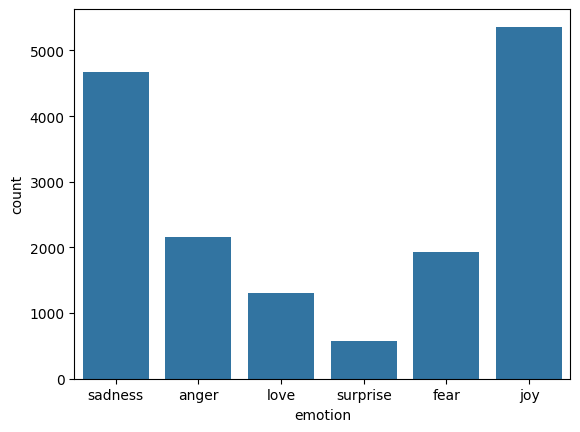

In [43]:
sns.countplot(x="emotion", data=train_df)
plt.show()

## Text Preprocessing

In [44]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r"[^a-z\s]", "", text)
    
    return text

In [45]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [46]:
train_df[["text", "clean_text"]].head()

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


## Define Features and Labels

In [47]:
X_train = train_df["clean_text"]
y_train = train_df["emotion"]

X_val = val_df["clean_text"]
y_val = val_df["emotion"]

X_test = test_df["clean_text"]
y_test = test_df["emotion"]

## Feature Extraction with TF-IDF

In [48]:
vectorizer = TfidfVectorizer()

In [49]:
X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)

In [50]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16000, 15186)
X_val shape: (2000, 15186)
X_test shape: (2000, 15186)


In [51]:
vectorizer.get_feature_names_out()[:20]

array(['aa', 'aaaaaaand', 'aaaaand', 'aaaand', 'aac', 'aahhh', 'aaron',
       'ab', 'abandon', 'abandoned', 'abandoning', 'abandonment',
       'abated', 'abbigail', 'abc', 'abdomen', 'abdominal', 'abducted',
       'abelard', 'abhorrent'], dtype=object)

## Baseline Model: Logistic Regression

In [52]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [53]:
y_val_pred = lr_model.predict(X_val)

## Model Evaluation

In [55]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8595

Classification Report:

              precision    recall  f1-score   support

       anger       0.91      0.81      0.86       275
        fear       0.86      0.73      0.79       212
         joy       0.84      0.95      0.89       704
        love       0.88      0.62      0.73       178
     sadness       0.86      0.94      0.90       550
    surprise       0.85      0.58      0.69        81

    accuracy                           0.86      2000
   macro avg       0.87      0.77      0.81      2000
weighted avg       0.86      0.86      0.85      2000

